In [ ]:
import sys
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make src/ importable when running from notebooks/
sys.path.append("..")

from src.styles.colors import get_colors

In [8]:
# ── Colour setup ──────────────────────────────────────────────────────────────
COLOR       = get_colors("palette")          # dict: name → hex
ARDS_COLORS = get_colors("ards")             # dict: ARDS label → hex
COLORS      = get_colors("categorical")      # list for categorical data
COLORS_SEQ_TEAL   = get_colors("sequential_teal")
COLORS_SEQ_ORANGE = get_colors("sequential_orange")

In [27]:
n = 600 # number of samples
frac_ards = 0.2 # fraction of samples in class ards
frac_control = 1 - frac_ards # fraction of samples in class control

def sample_gaussian_mixture(n, weights, means, stds, rng=None):
    """
    Sample from a univariate Gaussian mixture.

    Parameters
    ----------
    n : int
        Number of samples.
    weights : array-like (K,)
        Mixture weights (must sum to 1).
    means : array-like (K,)
        Component means.
    stds : array-like (K,)
        Component standard deviations.
    rng : np.random.Generator or None
        Random generator.

    Returns
    -------
    y : ndarray (n,)
        Samples from the mixture.
    z : ndarray (n,)
        Component indices.
    """
    rng = np.random.default_rng(rng)

    weights = np.asarray(weights)
    means = np.asarray(means)
    stds = np.asarray(stds)

    K = len(weights)

    # Sample component indices
    z = rng.choice(K, size=n, p=weights)

    # Sample from the corresponding Gaussian
    y = rng.normal(loc=means[z], scale=stds[z])

    return y, z

def sample_control(n_control):
    rho = 0.8
    cov_matrix = np.eye(5)
    cov_matrix[2, 3] = rho
    cov_matrix[3, 2] = rho

    return np.random.multivariate_normal(mean=np.zeros(5), cov=cov_matrix, size=n_control)

def sample_ards(n_ards):
    rho = 0.8

    X1 = np.random.normal(loc=1, scale=1, size=n_ards)
    X2 = sample_gaussian_mixture(n_ards, weights=[0.5, 0.5], means=[-1, 1], stds=[1, 1])[0]
    X34 = np.random.multivariate_normal(mean=np.zeros(2), cov=[[1, -rho], [-rho, 1]], size=n_ards)
    X5 = np.random.normal(loc=0, scale=1, size=n_ards)
    X = np.column_stack((X1, X2, X34, X5))
    return X

# sample data
n_control = int(n * frac_control)
n_ards = n - n_control
control_data = sample_control(n_control)
ards_data = sample_ards(n_ards)

# combine and create datafarme with ards label (0 for control, 1 for ards)
data = np.vstack((control_data, ards_data))
columns = [f'X{i}' for i in range(1, 6)]
df = pd.DataFrame(data, columns=columns)
df['ards'] = [0] * n_control + [1] * n_ards
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head()

ards_df = df[df['ards'] == 1]
control_df = df[df['ards'] == 0]

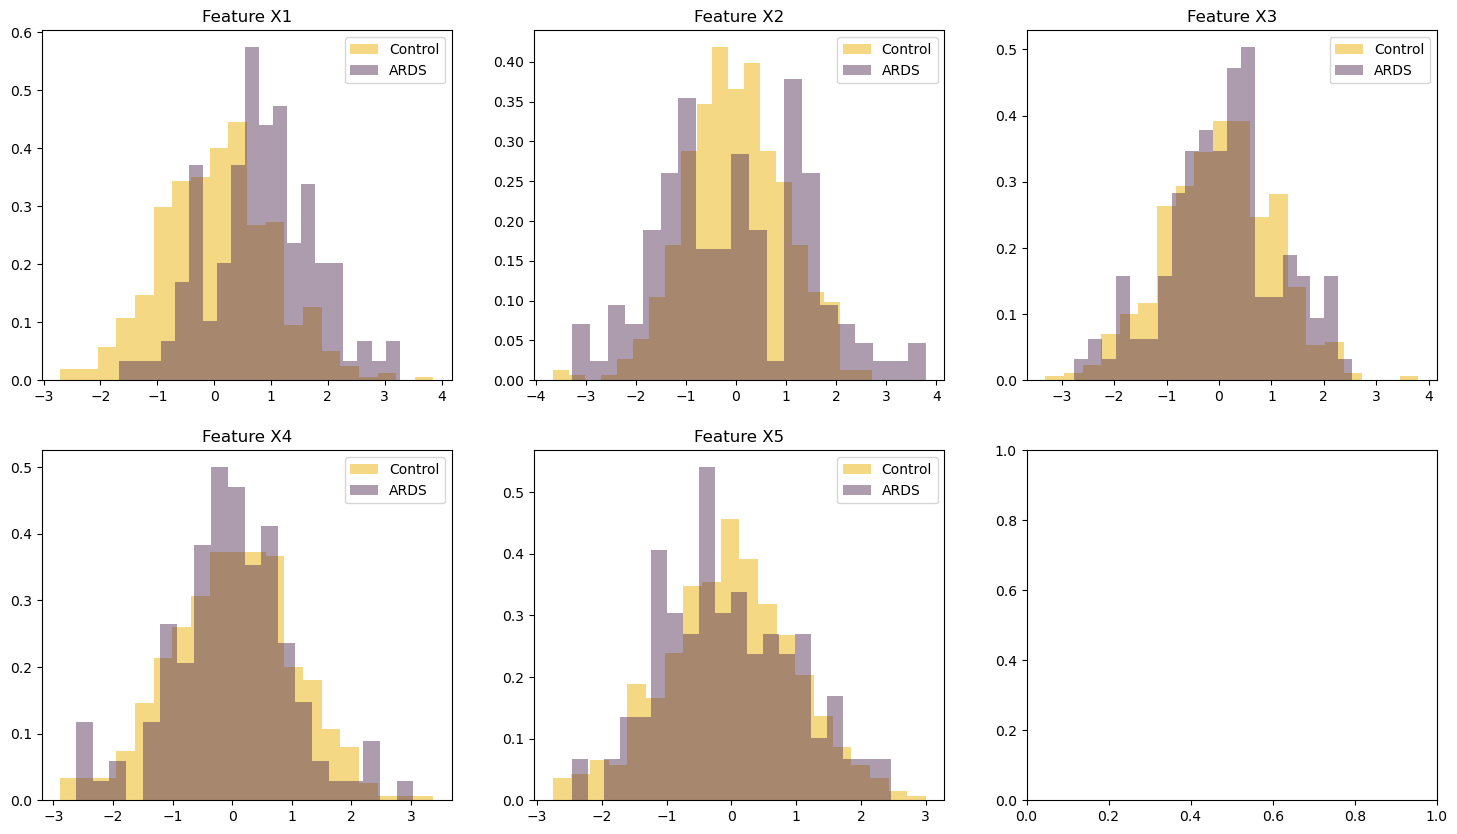

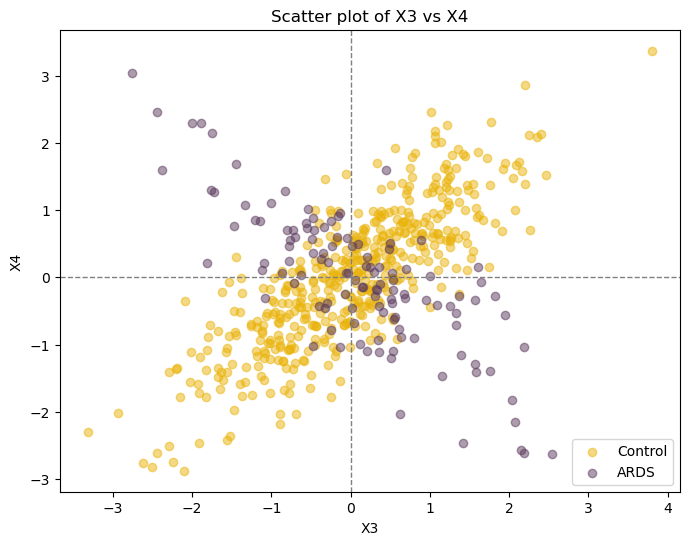

In [28]:
# Plot distributions of features based on ARDS label
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i in range(5):
    ax = axes[i]
    ax.hist(control_df[f'X{i+1}'], bins=20, alpha=0.5, label='Control', density=True, color=ARDS_COLORS["Not ARDS"])
    ax.hist(ards_df[f'X{i+1}'], bins=20, alpha=0.5, label='ARDS', density=True, color=ARDS_COLORS["ARDS"])
    ax.set_title(f'Feature X{i+1}')
    ax.legend()

# Scatter plot of X3 vs X4 colored by ARDS label
plt.figure(figsize=(8, 6))
plt.scatter(control_df['X3'], control_df['X4'], alpha=0.5, label='Control', color=ARDS_COLORS["Not ARDS"])
plt.scatter(ards_df['X3'], ards_df['X4'], alpha=0.5, label='ARDS', color=ARDS_COLORS["ARDS"])
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('X3')
plt.ylabel('X4')
plt.title('Scatter plot of X3 vs X4')
plt.legend()
plt.show()


In [33]:
from src.core.info_utils import mutual_information_cd, interaction_information_ccd
# Compute mutual information between each feature and ARDS label

X = df.drop(columns='ards').values
y = df['ards'].values

mi_scores = mutual_information_cd(X, y, method="sklearn")
print("Mutual Information Scores:")
for i, score in enumerate(mi_scores):
    print(f"Feature X{i+1}: {score:.4f}")

# Compute interaction information between pairs of features and ARDS label
feature_names = [f'X{i}' for i in range(1, 6)]
print("\nInteraction Information Scores:")
for i, j in itertools.combinations(range(X.shape[1]), 2):
    ii_score = interaction_information_ccd(X[:, i], X[:, j], y, method="sklearn")
    print(f"Features {feature_names[i]} & {feature_names[j]}: {ii_score:.4f}")

Mutual Information Scores:
Feature X1: 0.0369
Feature X2: 0.0394
Feature X3: 0.0000
Feature X4: 0.0000
Feature X5: 0.0137

Interaction Information Scores:
Features X1 & X2: 0.0000
Features X1 & X3: 0.0000
Features X1 & X4: -0.0294
Features X1 & X5: -0.0172
Features X2 & X3: -0.0364
Features X2 & X4: -0.0090
Features X2 & X5: -0.0474
Features X3 & X4: -0.2148
Features X3 & X5: -0.0125
Features X4 & X5: 0.0000
